EMPLOYEE PROMOTION PREDICTION - DECISION TREE

Dataset Shape: (300, 4)

Columns:
['date_of_birth', 'date_of_joining', 'gender', 'promoted']

Missing Values:
date_of_birth      0
date_of_joining    0
gender             0
promoted           0
dtype: int64

First 5 Rows:
  date_of_birth date_of_joining  gender promoted
0    26-07-1983      09-11-2021    male       no
1    24-01-1989      06-01-2015  female       no
2    22-10-1967      19-01-2019    male       no
3    23-03-1990      18-05-2017    male       no
4    28-02-1980      07-08-2008  female      yes

------------------------------------------------------------
FEATURE ENGINEERING
------------------------------------------------------------
Model Features:
- age_at_joining
- joining_year
- years_of_service
- gender_encoded

Number of Features: 4

Target Distribution:
Not Promoted (0): 134
Promoted (1): 166

------------------------------------------------------------
TRAIN-TEST SPLIT
----------------------------------------------

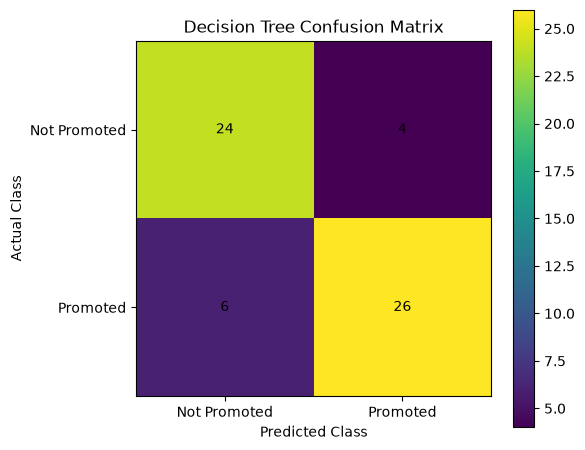


FINAL EXPERIMENT SUMMARY
Dataset            : Employee Promotions
Algorithm          : Decision Tree
Implementation     : From Scratch
Split Criterion    : Gini Impurity
Max Depth          : 5
Features           : 4
Training Samples   : 240
Testing Samples    : 60
Accuracy           : 83.33%
Macro Precision    : 0.8333
Macro Recall       : 0.8348
Macro F1           : 0.8331

Experiment completed successfully.


In [1]:
# ============================================================
# ASSIGNMENT 4: EMPLOYEE PROMOTION PREDICTION
# DECISION TREE FROM SCRATCH
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATASET
# ============================================================

file_path = "employee_promotions.csv"

df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

print("=" * 60)
print("EMPLOYEE PROMOTION PREDICTION - DECISION TREE")
print("=" * 60)

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. DATE PREPROCESSING
# ============================================================

df["date_of_birth"] = pd.to_datetime(
    df["date_of_birth"],
    format="%d-%m-%Y"
)

df["date_of_joining"] = pd.to_datetime(
    df["date_of_joining"],
    format="%d-%m-%Y"
)


# ============================================================
# 3. FEATURE ENGINEERING
# ============================================================

# Age at the time of joining
df["age_at_joining"] = (
    df["date_of_joining"] - df["date_of_birth"]
).dt.days / 365.25

# Convert joining date into year
df["joining_year"] = (
    df["date_of_joining"].dt.year
)

# Years of service relative to the latest joining year
latest_year = df["joining_year"].max()

df["years_of_service"] = (
    latest_year - df["joining_year"]
)

# Encode gender
df["gender_encoded"] = (
    df["gender"]
    .str.lower()
    .map({
        "male": 0,
        "female": 1
    })
)


# ============================================================
# 4. ENCODE TARGET
# ============================================================

df["promoted_encoded"] = (
    df["promoted"]
    .str.lower()
    .map({
        "no": 0,
        "yes": 1
    })
)


# ============================================================
# 5. CREATE MODEL DATA
# ============================================================

features = [
    "age_at_joining",
    "joining_year",
    "years_of_service",
    "gender_encoded"
]

X = df[features].values.astype(float)

y = df["promoted_encoded"].values.astype(int)

print("\n" + "-" * 60)
print("FEATURE ENGINEERING")
print("-" * 60)

print("Model Features:")

for feature in features:
    print("-", feature)

print("\nNumber of Features:", X.shape[1])

print("\nTarget Distribution:")

target_counts = pd.Series(
    y
).value_counts().sort_index()

print(
    "Not Promoted (0):",
    target_counts.get(0, 0)
)

print(
    "Promoted (1):",
    target_counts.get(1, 0)
)


# ============================================================
# 6. TRAIN-TEST SPLIT FROM SCRATCH
# ============================================================

np.random.seed(42)

indices = np.arange(len(X))

np.random.shuffle(indices)

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]

test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("\n" + "-" * 60)
print("TRAIN-TEST SPLIT")
print("-" * 60)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))


# ============================================================
# 7. DECISION TREE NODE
# ============================================================

class Node:

    def __init__(
        self,
        feature=None,
        threshold=None,
        left=None,
        right=None,
        value=None
    ):

        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value


# ============================================================
# 8. DECISION TREE FROM SCRATCH
# ============================================================

class DecisionTreeFromScratch:

    def __init__(
        self,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5
    ):

        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.root = None


    # --------------------------------------------------------
    # GINI IMPURITY
    # --------------------------------------------------------

    def gini(self, y):

        if len(y) == 0:
            return 0

        classes, counts = np.unique(
            y,
            return_counts=True
        )

        probabilities = counts / len(y)

        return 1 - np.sum(
            probabilities ** 2
        )


    # --------------------------------------------------------
    # INFORMATION GAIN
    # --------------------------------------------------------

    def information_gain(
        self,
        parent_y,
        left_y,
        right_y
    ):

        parent_impurity = self.gini(
            parent_y
        )

        n = len(parent_y)

        n_left = len(left_y)
        n_right = len(right_y)

        if n_left == 0 or n_right == 0:
            return 0

        weighted_child_impurity = (

            (n_left / n)
            * self.gini(left_y)

            +

            (n_right / n)
            * self.gini(right_y)
        )

        return (
            parent_impurity
            -
            weighted_child_impurity
        )


    # --------------------------------------------------------
    # FIND BEST SPLIT
    # --------------------------------------------------------

    def best_split(self, X, y):

        best_gain = -1

        best_feature = None

        best_threshold = None

        n_samples, n_features = X.shape

        for feature in range(n_features):

            values = np.unique(
                X[:, feature]
            )

            # Candidate thresholds
            # are midpoints between
            # consecutive values.

            if len(values) > 1:

                thresholds = (
                    values[:-1]
                    + values[1:]
                ) / 2

            else:

                thresholds = []


            for threshold in thresholds:

                left_mask = (
                    X[:, feature]
                    <= threshold
                )

                right_mask = ~left_mask

                left_count = np.sum(
                    left_mask
                )

                right_count = np.sum(
                    right_mask
                )

                if (
                    left_count
                    < self.min_samples_leaf
                    or
                    right_count
                    < self.min_samples_leaf
                ):
                    continue

                left_y = y[left_mask]

                right_y = y[right_mask]

                gain = self.information_gain(
                    y,
                    left_y,
                    right_y
                )

                if gain > best_gain:

                    best_gain = gain

                    best_feature = feature

                    best_threshold = threshold


        return (
            best_feature,
            best_threshold,
            best_gain
        )


    # --------------------------------------------------------
    # BUILD TREE RECURSIVELY
    # --------------------------------------------------------

    def build_tree(
        self,
        X,
        y,
        depth=0
    ):

        num_samples = len(y)

        num_classes = len(
            np.unique(y)
        )

        # Majority class

        values, counts = np.unique(
            y,
            return_counts=True
        )

        majority_class = values[
            np.argmax(counts)
        ]


        # Stopping conditions

        if (
            depth >= self.max_depth
            or
            num_classes == 1
            or
            num_samples
            < self.min_samples_split
        ):

            return Node(
                value=majority_class
            )


        # Find best split

        (
            best_feature,
            best_threshold,
            best_gain
        ) = self.best_split(
            X,
            y
        )


        # No useful split

        if (
            best_feature is None
            or
            best_gain <= 0
        ):

            return Node(
                value=majority_class
            )


        # Split data

        left_mask = (
            X[:, best_feature]
            <= best_threshold
        )

        right_mask = ~left_mask


        # Recursively build children

        left_subtree = self.build_tree(
            X[left_mask],
            y[left_mask],
            depth + 1
        )

        right_subtree = self.build_tree(
            X[right_mask],
            y[right_mask],
            depth + 1
        )


        return Node(
            feature=best_feature,
            threshold=best_threshold,
            left=left_subtree,
            right=right_subtree
        )


    # --------------------------------------------------------
    # FIT
    # --------------------------------------------------------

    def fit(self, X, y):

        self.root = self.build_tree(
            X,
            y
        )


    # --------------------------------------------------------
    # PREDICT ONE SAMPLE
    # --------------------------------------------------------

    def predict_sample(
        self,
        x,
        node
    ):

        # Leaf node

        if node.value is not None:

            return node.value


        # Traverse tree

        if (
            x[node.feature]
            <= node.threshold
        ):

            return self.predict_sample(
                x,
                node.left
            )

        else:

            return self.predict_sample(
                x,
                node.right
            )


    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    def predict(self, X):

        predictions = []

        for x in X:

            predictions.append(
                self.predict_sample(
                    x,
                    self.root
                )
            )

        return np.array(
            predictions
        )


# ============================================================
# 9. TRAIN MODEL
# ============================================================

model = DecisionTreeFromScratch(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5
)

model.fit(
    X_train,
    y_train
)

y_pred = model.predict(
    X_test
)


# ============================================================
# 10. ACCURACY
# ============================================================

accuracy = np.mean(
    y_pred == y_test
)

print("\n" + "-" * 60)
print("MODEL RESULTS")
print("-" * 60)

print(
    "Algorithm          : Decision Tree"
)

print(
    "Implementation     : From Scratch using NumPy"
)

print(
    "Split Criterion    : Gini Impurity"
)

print(
    "Max Depth          :",
    model.max_depth
)

print(
    "Min Samples Split  :",
    model.min_samples_split
)

print(
    "Min Samples Leaf   :",
    model.min_samples_leaf
)

print(
    "Training Samples   :",
    len(X_train)
)

print(
    "Testing Samples    :",
    len(X_test)
)

print(
    f"\nAccuracy           : "
    f"{accuracy:.4f}"
)

print(
    f"Accuracy (%)       : "
    f"{accuracy * 100:.2f}%"
)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

confusion_matrix = np.zeros(
    (2, 2),
    dtype=int
)

for actual, predicted in zip(
    y_test,
    y_pred
):

    confusion_matrix[
        actual,
        predicted
    ] += 1


print("\nConfusion Matrix:")

print(
    confusion_matrix
)


# ============================================================
# 12. PRECISION / RECALL / F1
# ============================================================

precision_list = []

recall_list = []

f1_list = []


for class_id in [0, 1]:

    tp = confusion_matrix[
        class_id,
        class_id
    ]

    fp = (
        np.sum(
            confusion_matrix[
                :,
                class_id
            ]
        )
        - tp
    )

    fn = (
        np.sum(
            confusion_matrix[
                class_id,
                :
            ]
        )
        - tp
    )


    precision = (
        tp / (tp + fp)
        if tp + fp > 0
        else 0
    )

    recall = (
        tp / (tp + fn)
        if tp + fn > 0
        else 0
    )

    f1 = (
        2 * precision * recall
        /
        (precision + recall)
        if precision + recall > 0
        else 0
    )


    precision_list.append(
        precision
    )

    recall_list.append(
        recall
    )

    f1_list.append(
        f1
    )


    class_name = (
        "Not Promoted"
        if class_id == 0
        else "Promoted"
    )

    print(
        f"\n{class_name}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1 Score : {f1:.4f}"
    )


macro_precision = np.mean(
    precision_list
)

macro_recall = np.mean(
    recall_list
)

macro_f1 = np.mean(
    f1_list
)


print(
    f"\nMacro Precision: "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall   : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1 Score : "
    f"{macro_f1:.4f}"
)


# ============================================================
# 13. SAVE PREDICTIONS
# ============================================================

output_df = pd.DataFrame({

    "Actual Status": [
        "Promoted" if value == 1
        else "Not Promoted"
        for value in y_test
    ],

    "Predicted Status": [
        "Promoted" if value == 1
        else "Not Promoted"
        for value in y_pred
    ],

    "Correct":
        y_test == y_pred
})


output_df.to_csv(
    "decision_tree_output.csv",
    index=False
)


print(
    "\nPrediction output saved as:"
)

print(
    "decision_tree_output.csv"
)


# ============================================================
# 14. SAMPLE PREDICTIONS
# ============================================================

print("\n" + "-" * 60)

print(
    "SAMPLE PREDICTIONS"
)

print(
    "-" * 60
)

print(
    output_df.head(10)
    .to_string(index=False)
)


# ============================================================
# 15. CONFUSION MATRIX PLOT
# ============================================================

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    confusion_matrix,
    interpolation="nearest"
)

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    [0, 1],
    ["Not Promoted", "Promoted"]
)

plt.yticks(
    [0, 1],
    ["Not Promoted", "Promoted"]
)


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )


plt.colorbar()

plt.tight_layout()

plt.show()


# ============================================================
# 16. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)

print(
    "FINAL EXPERIMENT SUMMARY"
)

print(
    "=" * 60
)

print(
    "Dataset            : Employee Promotions"
)

print(
    "Algorithm          : Decision Tree"
)

print(
    "Implementation     : From Scratch"
)

print(
    "Split Criterion    : Gini Impurity"
)

print(
    "Max Depth          :",
    model.max_depth
)

print(
    "Features           :",
    X.shape[1]
)

print(
    "Training Samples   :",
    len(X_train)
)

print(
    "Testing Samples    :",
    len(X_test)
)

print(
    f"Accuracy           : "
    f"{accuracy * 100:.2f}%"
)

print(
    f"Macro Precision    : "
    f"{macro_precision:.4f}"
)

print(
    f"Macro Recall       : "
    f"{macro_recall:.4f}"
)

print(
    f"Macro F1           : "
    f"{macro_f1:.4f}"
)

print(
    "\nExperiment completed successfully."
)